# Calculating Expected Field Goal% (xFG%)

$xFG(x) = P$(`SHOT_MADE` $=1∣$ Shot Context)

### Features Used
| Feature                        | Why                       |
| ------------------------------ | ------------------------- |
| Shot location (x, y)           | Geometry                  |
| Shot distance                  | Nonlinear effect          |
| Shot angle                     | Corner vs above-the-break |
| Shot type (2PT / 3PT)          | Massive baseline shift    |
| Corner 3 indicator             | Known efficiency bump     |
| Shot clock time                | Rush effect               |
| Catch-and-shoot vs off-dribble | Difficulty                |
| Dribble count                  | Proxy for creation        |


In [1]:
# Imports
from __future__ import annotations
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import log_loss, brier_score_loss
import matplotlib.pyplot as plt
from nba_api.stats.endpoints import shotchartdetail
import numpy as np
import pandas as pd


In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent   # if notebook is in /notebooks
sys.path.append(str(ROOT))

from src.data_io.save_load import load_json, load_dataframe

from src.features.shot_maps import build_player_maps, make_player_maps
from src.data_io.maps import save_maps_npz



## Import Data

In [3]:
shots_raw = shotchartdetail.ShotChartDetail(
    team_id=0,                    # all teams
    player_id=0,                  # all players
    season_nullable="2015-16",
    season_type_all_star="Regular Season",
    context_measure_simple="FGA"  # field goal attempts
).get_data_frames()[0]


In [4]:
shots = shots_raw.copy()
# Coord Normalization
shots["x_ft"] = shots["LOC_X"] / 12
shots["y_ft"] = shots["LOC_Y"] / 12

shots["shot_dist"] = np.sqrt(shots.x_ft**2 + shots.y_ft**2)
shots["angle"] = np.arctan2(shots.x_ft, shots.y_ft)

# Shot Type
shots["is_three"] = shots["SHOT_TYPE"].str.contains("3PT").astype(int)
shots["is_corner"] = ((np.abs(shots.x_ft) > 22) & (shots.y_ft < 14)).astype(int)

# Shot Zone
shots['SHOT_ZONE_BASIC'] = shots['SHOT_ZONE_BASIC'].astype(str)

# Make Sure Game ID is int
shots['GAME_ID'] = shots['GAME_ID'].astype(int)

# Remove any shots past halfcourt
shots = shots[(shots["y_ft"] >= -5) & (shots["y_ft"] <= 42)]
shots = shots.reset_index(drop=True)


## Calculate xFG with Offensive Stats
Use shot chart data to calculate expected field goal for all shots

### Feature Pipeline

In [5]:
feature_cols_num = [
    "shot_dist",
    "angle",
    "is_three",
    "is_corner",
]

feature_cols_cat = ["SHOT_ZONE_BASIC"]

missing = [c for c in (feature_cols_num + feature_cols_cat) if c not in shots.columns]
if missing:
    raise ValueError(f"Missing features in shots: {missing}")

preprocess = ColumnTransformer([
    ("num", StandardScaler(), feature_cols_num),
    ("cat", OneHotEncoder(drop="first"), feature_cols_cat)
])

shots.fillna(0, inplace=True)

#### Test Train Split
60/20/20

In [6]:
shots["GAME_DATE"] = pd.to_datetime(shots["GAME_DATE"].astype(str), format="%Y%m%d", errors="coerce")
train_idx = shots.index[shots["GAME_DATE"] < "2016-01-01"]
val_idx   = shots.index[(shots["GAME_DATE"] >= "2016-01-01") & (shots["GAME_DATE"] < "2016-02-15")]
test_idx  = shots.index[shots["GAME_DATE"] >= "2016-02-15"]

### MODEL
Here we fit a logistic regression model, using "shot_made" as our target, then also fit a calibrated model which makes our data more normal.

In [7]:
num_cols = feature_cols_num
cat_cols = feature_cols_cat  

# Ensure cat_cols are strings
for c in cat_cols:
    shots[c] = shots[c].astype(str)

X_train = shots.loc[train_idx, num_cols + cat_cols]
y_train = shots.loc[train_idx, "SHOT_MADE_FLAG"].astype(int)

X_val   = shots.loc[val_idx, num_cols + cat_cols]
y_val   = shots.loc[val_idx, "SHOT_MADE_FLAG"].astype(int)

X_test  = shots.loc[test_idx, num_cols + cat_cols]
y_test  = shots.loc[test_idx, "SHOT_MADE_FLAG"].astype(int)

prep = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

base_model = Pipeline([
    ("prep", prep),
    ("lr", LogisticRegression(
        l1_ratio=0.0,
        C=1.0,
        solver="lbfgs",
        max_iter=200
    ))
])

base_model.fit(X_train, y_train)

calibrator = CalibratedClassifierCV(
    estimator=base_model,
    method="isotonic"   # or "sigmoid" if you want smoother/less overfit
)

calibrator.fit(X_val, y_val)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-

CalibratedClassifierCV(estimator=Pipeline(steps=[('prep',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   StandardScaler(),
                                                                                   ['shot_dist',
                                                                                    'angle',
                                                                                    'is_three',
                                                                                    'is_corner']),
                                                                                  ('cat',
                                                                                   OneHotEncoder(handle_unknown='ignore'),
                                                                                   ['SHOT_ZONE_BASIC'])])),
                                                 ('lr',
                                                  LogisticRegression(l1_ratio=0.0,
                                                                     max_iter=200))]),
                       method='isotonic')

### Model Mectrics


In [8]:
def eval_probs(name, y_true, p):
    print(f"\n{name}")
    print("  log loss:", log_loss(y_true, p))
    print("  brier   :", brier_score_loss(y_true, p))

p_val  = calibrator.predict_proba(X_val)[:, 1]
p_test = calibrator.predict_proba(X_test)[:, 1]

eval_probs("Validation", y_val, p_val)
eval_probs("Test", y_test, p_test)


Validation
  log loss: 0.6507981711797179
  brier   : 0.23025401038274346

Test
  log loss: 0.6488665162825326
  brier   : 0.2288568675281168


#### Calibrate xFG

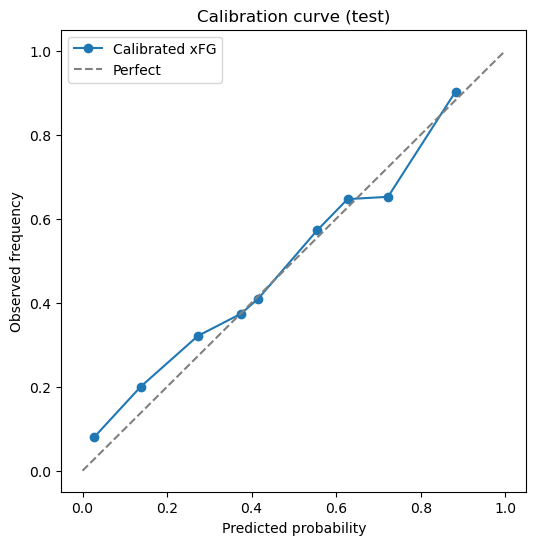

In [9]:
prob_true, prob_pred = calibration_curve(y_test, p_test, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o", label="Calibrated xFG")
plt.plot([0,1],[0,1], "--", color="gray", label="Perfect")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration curve (test)")
plt.legend()
plt.show()

### ADD Expected Points Per Shot

In [10]:
X_all = shots[feature_cols_num + feature_cols_cat].copy()
shots["xFG_base"]  = calibrator.predict_proba(X_all)[:,1]
shots["xPPS_base"] = shots["xFG_base"] * np.where(shots["is_three"], 3, 2)

## Add Offensive Impact of Player

In [11]:
alpha = 300
grp_cols = ["PLAYER_ID", "SHOT_ZONE_BASIC", "is_three"]

train = shots.loc[train_idx].copy()
league_rate = train["SHOT_MADE_FLAG"].mean()

grp = (
    train.groupby(grp_cols)["SHOT_MADE_FLAG"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "makes", "count": "atts"})
    .reset_index()
)

grp["player_prior"] = (grp["makes"] + alpha * league_rate) / (grp["atts"] + alpha)
# 
min_atts = 30
grp.loc[grp["atts"] < min_atts, "player_prior"] = league_rate

shots = shots.drop(columns=["player_prior"], errors="ignore")
shots = shots.merge(grp[grp_cols + ["player_prior"]], on=grp_cols, how="left")
shots["player_prior"] = shots["player_prior"].fillna(league_rate)

offense_features = ["xFG_base", "player_prior", "is_three"]
X2_train = shots.loc[train_idx, offense_features]
y2_train = shots.loc[train_idx, "SHOT_MADE_FLAG"].astype(int)

X2_val   = shots.loc[val_idx, offense_features]
y2_val   = shots.loc[val_idx, "SHOT_MADE_FLAG"].astype(int)

offense_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=1.0, solver="lbfgs", max_iter=500))
])

offense_model.fit(X2_train, y2_train)

offense_cal = CalibratedClassifierCV(offense_model, method="isotonic", cv="prefit")
offense_cal.fit(X2_val, y2_val)

shots["xFG_offense"] = offense_cal.predict_proba(shots[offense_features])[:, 1]
shots["xPPS_offense"] = shots["xFG_offense"] * np.where(shots["is_three"], 3, 2)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


### Save player impact in npz

In [12]:
maps, meta = build_player_maps(
    shots_processed,
    min_attempts=75,
    value_col="xPPS_offense",          # or xPPS_offense
    grid_kwargs=dict(x_min=-25, x_max=25, y_min=-5, y_max=42, bin_size=1.0),
    smooth_sigma=1.25
)

NameError: name 'shots_processed' is not defined

In [ ]:
# Save the maps to a .npz file for later use
# save_maps_npz("../data/processed/maps_1ft_xfg.npz", maps)

### Save shots as parquet

In [13]:
# Add game_clock column
shots["game_clock"] = (
    shots["MINUTES_REMAINING"] * 60
    + shots["SECONDS_REMAINING"]
)
shots['SHOT_EVENT_ID'] = shots['GAME_EVENT_ID']

# Tag only relevant columns for merging
relevant_columns = [
    'GAME_ID',
    'SHOT_EVENT_ID',
    'PERIOD',
    'game_clock',
    'PLAYER_ID',
    'TEAM_ID',
    'x_ft',
    'y_ft'
]

# Create filtered DataFrame
shots_filtered = shots[relevant_columns + ['xFG_offense', 'xPPS_offense', 'SHOT_MADE_FLAG']].copy()



In [14]:
print(shots_filtered.shape)
shots_filtered.head()
#shots_filtered.to_parquet("../data/processed/shots/all_season_shots.parquet", index=False)


(207630, 11)


,GAME_ID,SHOT_EVENT_ID,PERIOD,game_clock,PLAYER_ID,TEAM_ID,x_ft,y_ft,xFG_offense,xPPS_offense,SHOT_MADE_FLAG
0,21500001,2,1,701,203083,1610612765,-1.416667,-0.500000,0.584404,1.168807,0
1,21500001,5,1,681,202694,1610612765,9.750000,5.583333,0.402172,0.804343,1
2,21500001,6,1,660,200794,1610612737,6.333333,7.916667,0.377188,0.754377,1
3,21500001,7,1,644,203484,1610612765,-5.666667,4.250000,0.380143,0.760285,1
4,21500001,8,1,627,201143,1610612737,-9.750000,13.666667,0.394537,0.789074,0
